In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, tqdm, glob, hdf5plugin
os.environ["JAX_PLATFORM_NAME"] = "cpu"
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import jax_cosmo as jc

import jaxpm
from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.utils import power_spectrum, cross_correlation_coefficients
from jaxpm import camels, plotting
jax.devices()

[CpuDevice(id=0)]

In [3]:
# mesh_per_dim = 256
# parts_per_dim = None

mesh_per_dim = 64
parts_per_dim = mesh_per_dim

mesh_shape = [mesh_per_dim] * 3

In [4]:
# # SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0"
# SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0"
# # SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/Astrid/CV/CV_0"

# hydro_dict = camels.load_CV_snapshots(
#     SIM,
#     mesh_per_dim,
#     parts_per_dim,
#     i_snapshots=[0, -1],
#     # i_snapshots=range(1, 33+8, 8),
#     return_hydro=True,
# )

# h_dm_poss = hydro_dict["dm_poss"]
# h_dm_masss = hydro_dict["dm_masss"]
# h_gas_poss = hydro_dict["gas_poss"]
# h_gas_masss = hydro_dict["gas_masss"]

Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_014.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


finding unique gas particle indices:  50%|█████     | 1/2 [00:01<00:01,  1.60s/it]

Found 14787 duplicate gas particle IDs


finding unique gas particle indices: 100%|██████████| 2/2 [00:08<00:00,  4.13s/it]


There are 15915546 (94.86%) gas particles that exist in all snapshots


loading snapshots: 100%|██████████| 2/2 [00:41<00:00, 20.84s/it]

Could not stack cosmo
Could not stack mesh_per_dim


In [5]:
for h_gas_pos in h_gas_poss:
    print(h_gas_pos.shape)

(262144, 3)
(262144, 3)


# compare hydro CV for hydro codes

In [9]:
CAMELS = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims"
SIMSET = "CV/CV_0"

astrid = glob.glob(os.path.join(os.path.join(CAMELS, "Astrid", SIMSET), "snapshot_???.hdf5"))
astrid = [os.path.basename(snap) for snap in astrid]

illustris = glob.glob(os.path.join(os.path.join(CAMELS, "IllustrisTNG", SIMSET), "snapshot_???.hdf5"))
illustris = [os.path.basename(snap) for snap in illustris]

simba = glob.glob(os.path.join(os.path.join(CAMELS, "SIMBA", SIMSET), "snapshot_???.hdf5"))
simba = [os.path.basename(snap) for snap in simba]

snapshots = list(set(astrid) & set(illustris) & set(simba))
snapshots.sort()

sub_snapshots = [snapshots[i] for i in range(len(snapshots)-1, 0, -8)]
sub_snapshots.sort()

def compare_dm_and_gas(CODE, mesh_per_dim, parts_per_dim):
    nbody_dict = camels.load_CV_snapshots(
        os.path.join(CAMELS, CODE + "_DM", SIMSET),
        mesh_per_dim,
        parts_per_dim,
        snapshots=sub_snapshots,
        return_hydro=False,
    )

    
    hydro_dict = camels.load_CV_snapshots(
        os.path.join(CAMELS, CODE, SIMSET),
        mesh_per_dim,
        parts_per_dim,
        snapshots=sub_snapshots,
        return_hydro=True,
    )

    scales = hydro_dict["scales"]
    mesh_shape = [mesh_per_dim] * 3

    # variable number of gas particles
    n_rho_dm = []
    rho_dm = []
    rho_gas = []
    rho_tot = []
    for i in range(len(scales)):
        n_rho_dm.append(cic_paint(jnp.zeros(mesh_shape), nbody_dict["dm_poss"][i], 1))
        rho_dm.append(cic_paint(jnp.zeros(mesh_shape), hydro_dict["dm_poss"][i], 1))
        rho_gas.append(cic_paint(jnp.zeros(mesh_shape), hydro_dict["gas_poss"][i], 1))
        rho_tot.append(jnp.mean(hydro_dict["dm_masss"][i]) * rho_dm[i] + jnp.mean(hydro_dict["gas_masss"][i]) * rho_gas[i])

    n_rho_dm = jnp.stack(n_rho_dm, axis=0)
    rho_dm = jnp.stack(rho_dm, axis=0)
    rho_gas = jnp.stack(rho_gas, axis=0)
    rho_tot = jnp.stack(rho_tot, axis=0)

    plotting.compare_field_evolution(
        scales,
        jnp.stack([n_rho_dm, rho_dm, rho_gas, rho_tot], axis=0),
        include_pk=True,
        include_reference=True,
        # values
        shared_colorbar=True,
        # cosmetics
        title=f"CAMELS (hydro, {CODE})",
        col_titles=["dm (nbody)", "dm", "gas", "tot"],
        out_dir=f"plots/CAMELS_{CODE}_hydro_evolution_{mesh_per_dim}",
    )

    return hydro_dict


Selecting 262144 dark matter (deterministic)


loading snapshots: 100%|██████████| 5/5 [00:14<00:00,  2.98s/it]


Could not stack cosmo
Could not stack mesh_per_dim
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


finding unique gas particle indices: 100%|██████████| 5/5 [00:16<00:00,  3.39s/it]


There are 10469061 (62.40%) gas particles that exist in all snapshots


loading snapshots: 100%|██████████| 5/5 [01:47<00:00, 21.58s/it]


Could not stack cosmo
Could not stack mesh_per_dim


100%|██████████| 5/5 [00:04<00:00,  1.09it/s]


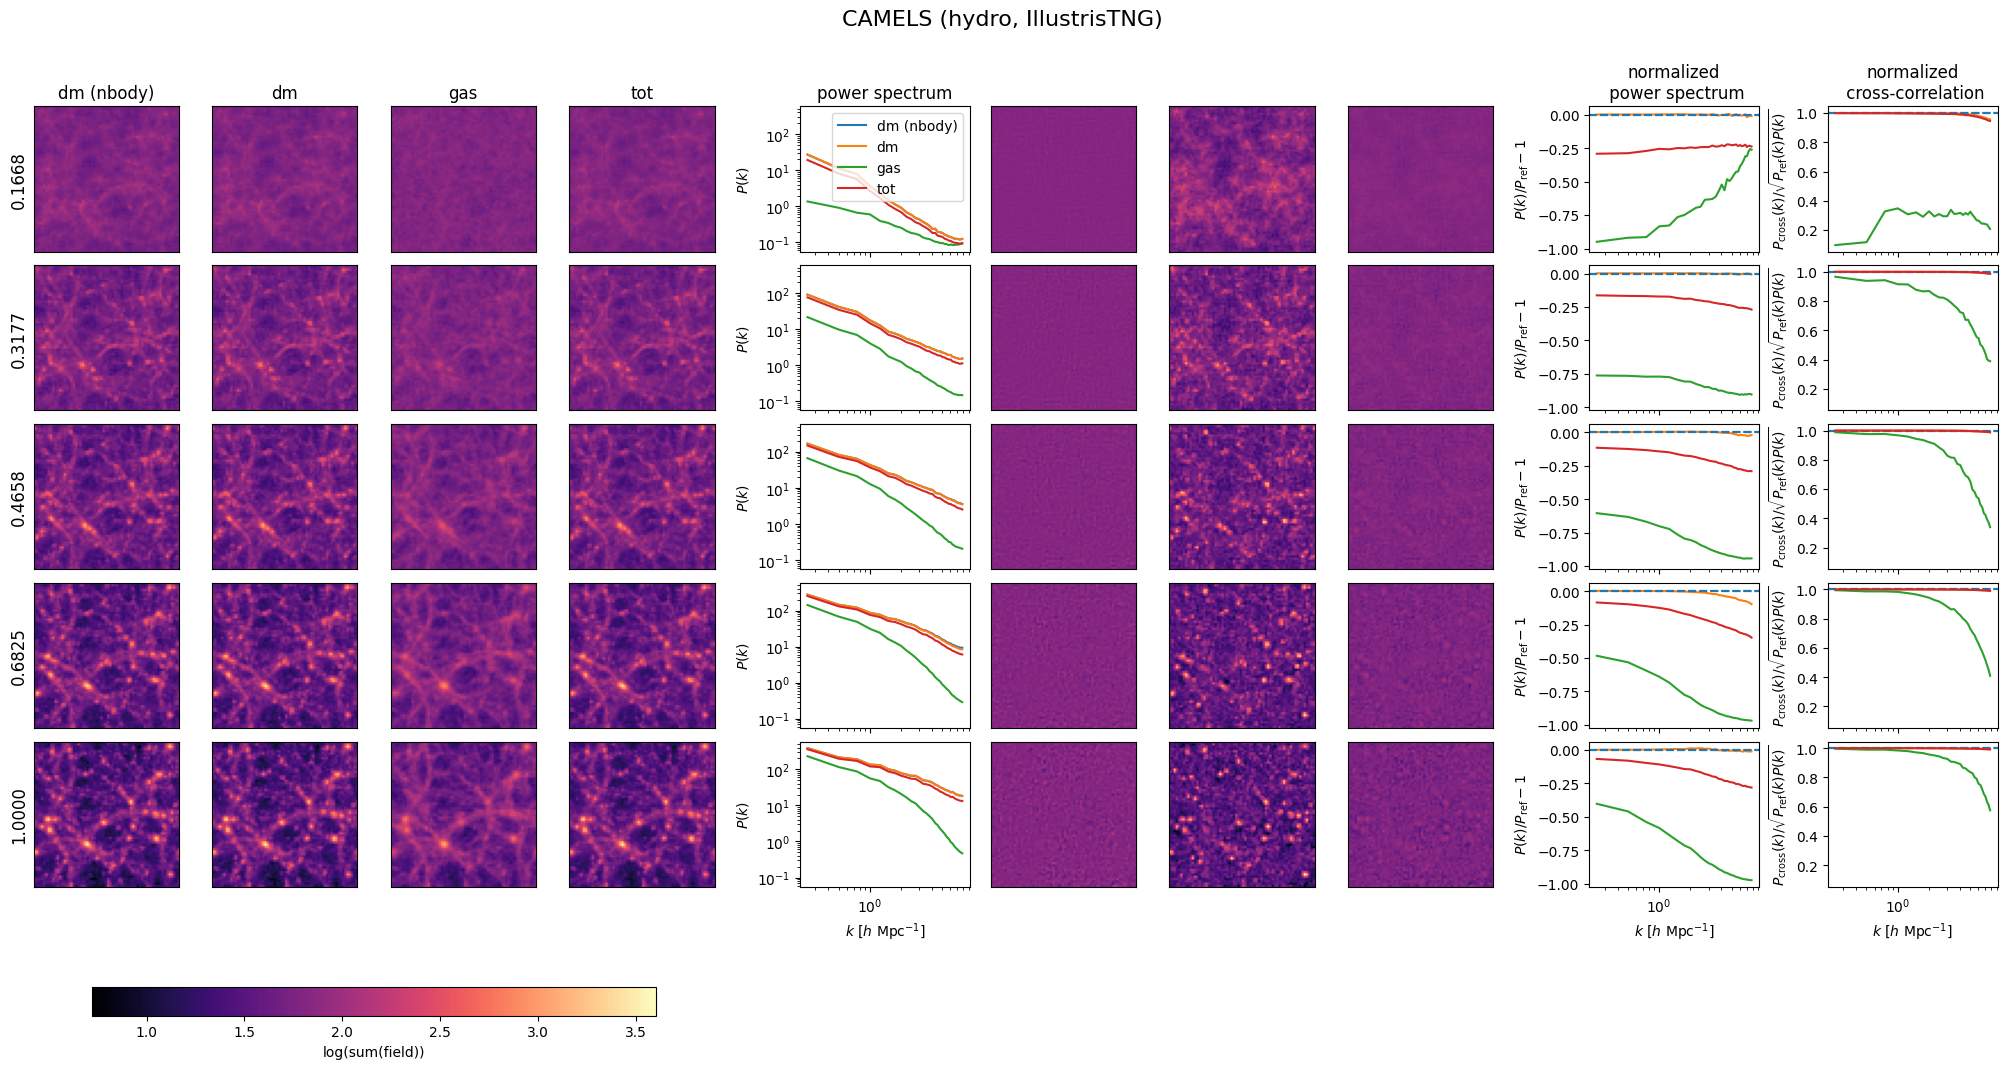

In [13]:
hydro_dict = compare_dm_and_gas("IllustrisTNG", 64, 64)

Selecting 262144 dark matter (deterministic)


loading snapshots: 100%|██████████| 5/5 [00:14<00:00,  2.89s/it]


Could not stack cosmo
Could not stack mesh_per_dim
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


finding unique gas particle indices:  20%|██        | 1/5 [00:01<00:05,  1.32s/it]

Found 368 duplicate gas particle IDs


...

finding unique gas particle indices: 100%|██████████| 5/5 [00:23<00:00,  4.69s/it]


There are 15915410 (94.86%) gas particles that exist in all snapshots


loading snapshots: 100%|██████████| 5/5 [01:33<00:00, 18.63s/it]


Could not stack cosmo
Could not stack mesh_per_dim


100%|██████████| 5/5 [00:04<00:00,  1.12it/s]


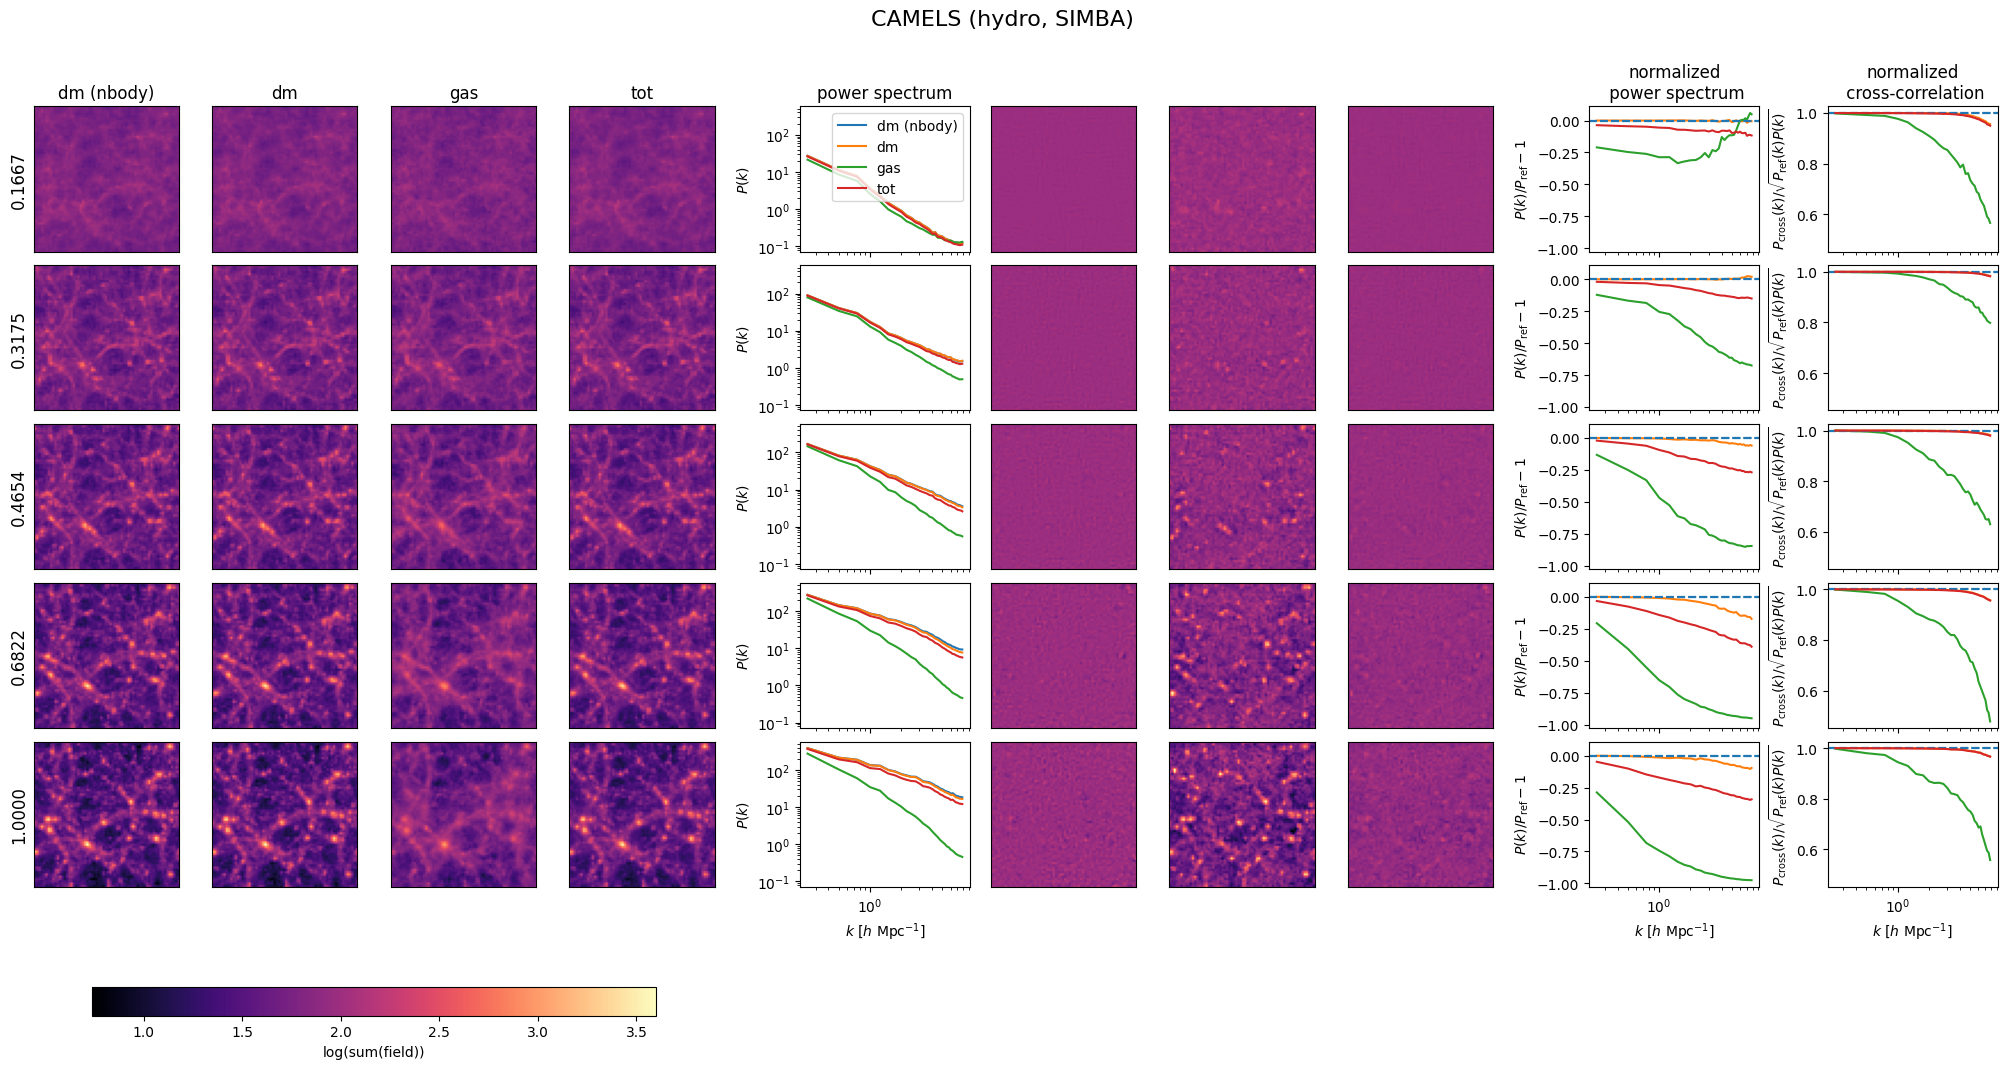

In [14]:
hydro_dict = compare_dm_and_gas("SIMBA", 64, 64)

Selecting 262144 dark matter (deterministic)


loading snapshots: 100%|██████████| 5/5 [00:14<00:00,  2.96s/it]


Could not stack cosmo
Could not stack mesh_per_dim
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


finding unique gas particle indices: 100%|██████████| 5/5 [00:29<00:00,  5.89s/it]


There are 16706476 (99.58%) gas particles that exist in all snapshots


loading snapshots: 100%|██████████| 5/5 [01:23<00:00, 16.79s/it]


Could not stack cosmo
Could not stack mesh_per_dim


100%|██████████| 5/5 [00:04<00:00,  1.13it/s]


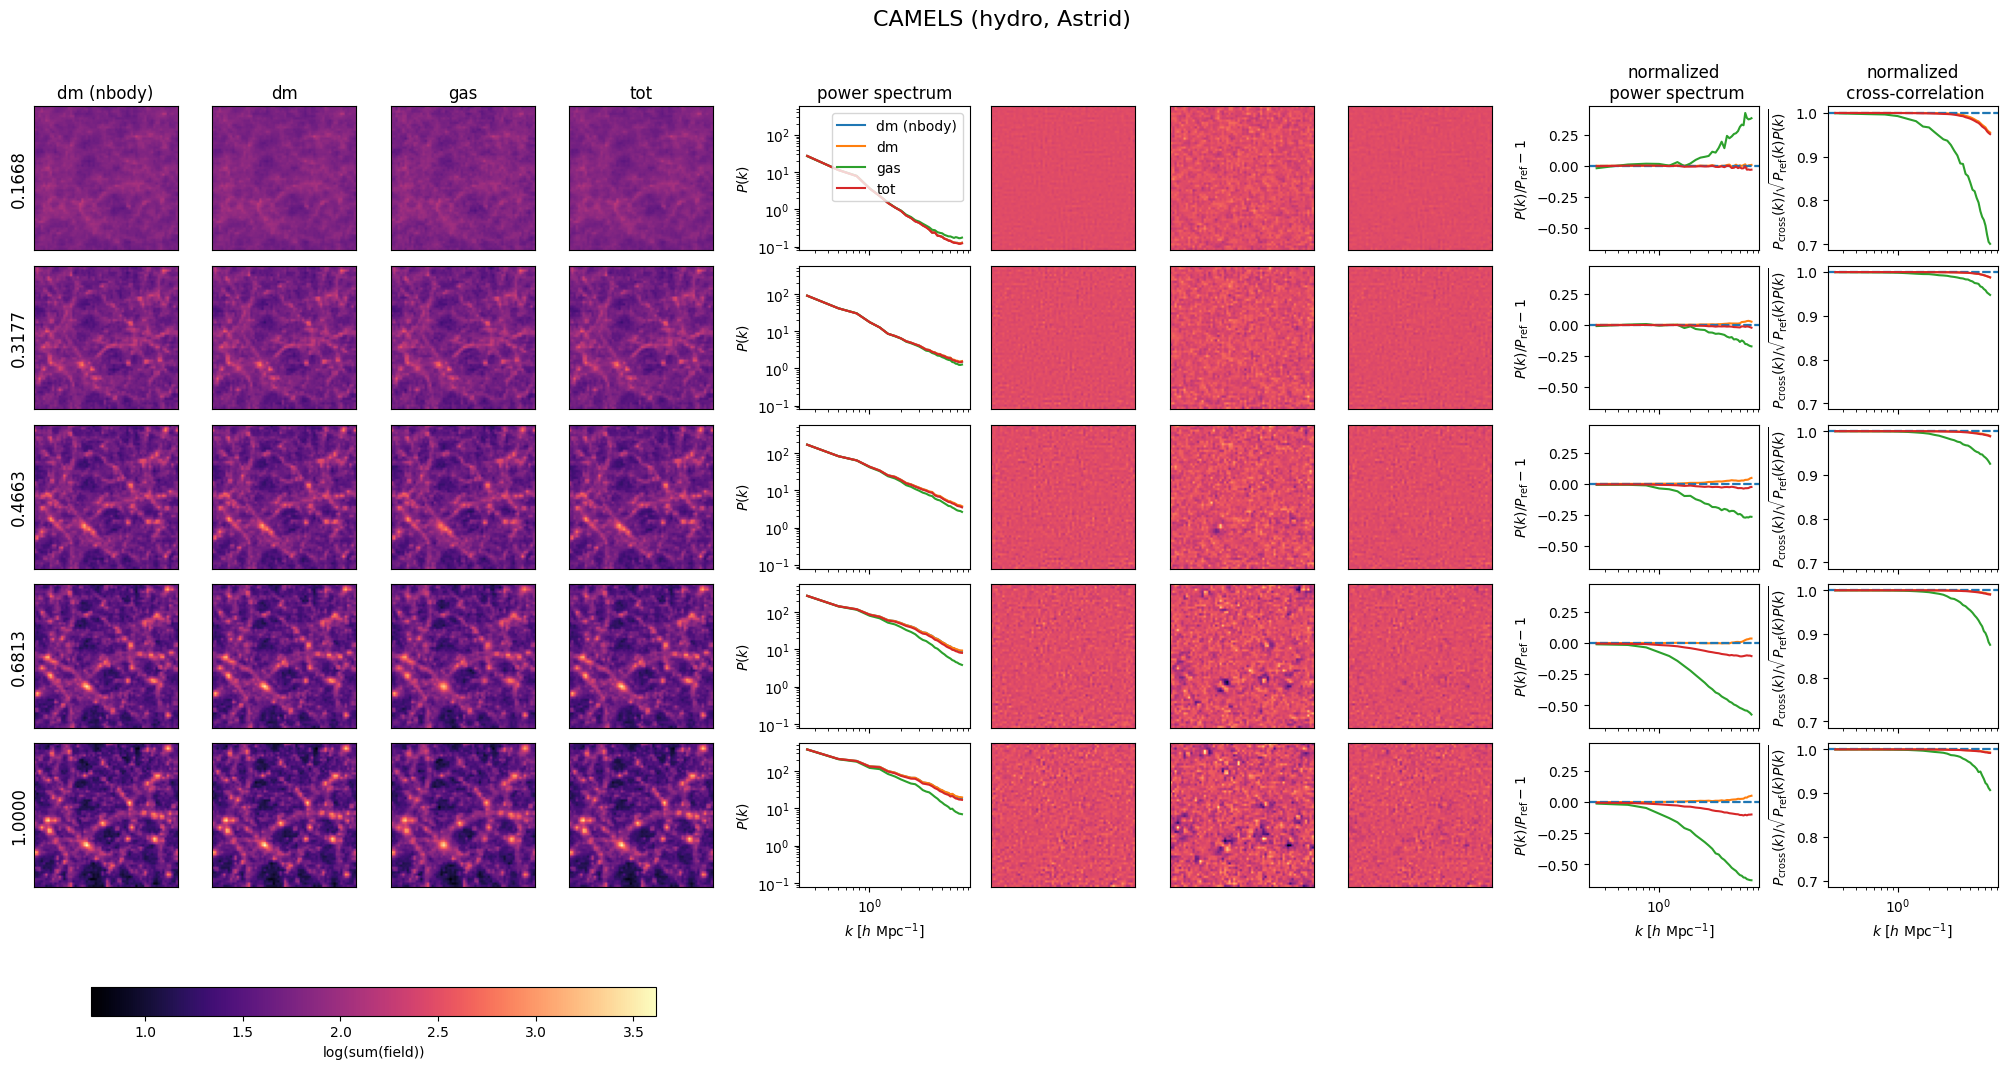

In [15]:
hydro_dict = compare_dm_and_gas("Astrid", 64, 64)

# particle mass

In [4]:
CAMELS = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims"
SIMSET = "CV/CV_0"

# i_snapshots = range(1, 33+8, 8)
i_snapshots = None
    
illustris_dict = camels.load_CV_snapshots(
    os.path.join(CAMELS, "IllustrisTNG", SIMSET),
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
    return_hydro=True,
)

simba_dict = camels.load_CV_snapshots(
    os.path.join(CAMELS, "SIMBA", SIMSET),
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
    return_hydro=True,
)

astrid_dict = camels.load_CV_snapshots(
    os.path.join(CAMELS, "Astrid", SIMSET),
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
    return_hydro=True,
)

Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


finding unique gas particle indices: 100%|██████████| 34/34 [02:15<00:00,  3.98s/it]


There are 10431082 (62.17%) gas particles that exist in all snapshots


loading snapshots: 100%|██████████| 34/34 [10:34<00:00, 18.66s/it]


Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


...

loading snapshots: 100%|██████████| 34/34 [13:21<00:00, 23.58s/it]


Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


finding unique gas particle indices: 100%|██████████| 46/46 [07:35<00:00,  9.91s/it]


There are 16706476 (99.58%) gas particles that exist in all snapshots


loading snapshots: 100%|██████████| 46/46 [19:23<00:00, 25.29s/it]


0
std = 0.033185191452503204
0.023679443
[0.0154635  0.01737687 0.02045946 0.02255099 0.02502351 0.02604645
 0.02705774 0.02798308 0.02890789 0.02975777 0.03061586 0.03149182
 0.03225619 0.03291413 0.03364407 0.03422916 0.03479206 0.0352199
 0.03568139 0.0361436  0.03651351 0.0367802  0.03702154 0.03720323
 0.03736181 0.03755344 0.03775517 0.03794175 0.03802101 0.03816101
 0.03833    0.03851551 0.03867505 0.0389323 ]
1
std = 0.007226011250168085
0.0010378419
[0.00027375 0.00053489 0.00088901 0.00122201 0.00157148 0.00184685
 0.00207834 0.0024484  0.00291296 0.0036208  0.00403819 0.00442608
 0.00481813 0.00510047 0.00548997 0.00582782 0.00624773 0.00661479
 0.00693767 0.00730983 0.0077758  0.00809121 0.00844436 0.00880993
 0.0091325  0.00948053 0.00974768 0.01006974 0.01036225 0.01064199
 0.01098861 0.01126639 0.0115437  0.01188114]
2
std = 0.010875671170651913
0.0024860527
[0.         0.00010658 0.00019081 0.00037595 0.00060871 0.00087771
 0.00124963 0.00159773 0.00198082 0.00262074 0.

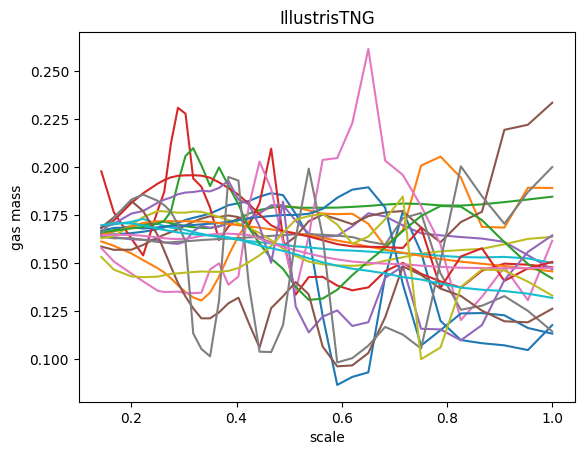

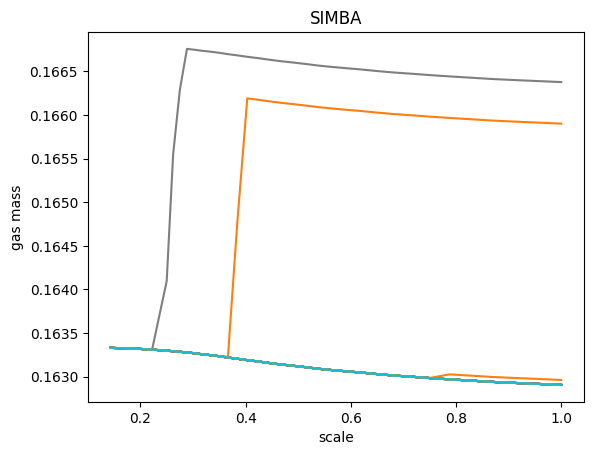

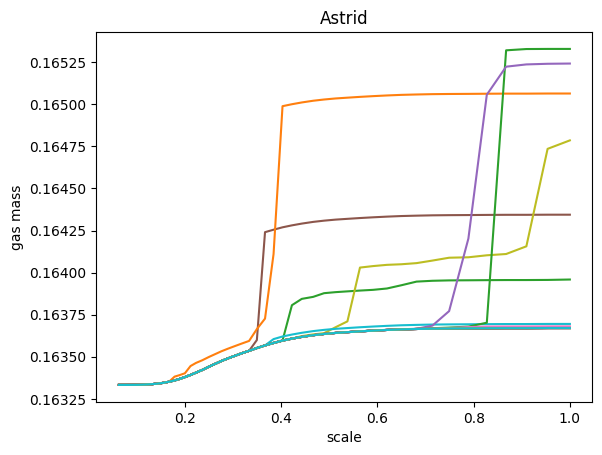

In [8]:
names = ["IllustrisTNG", "SIMBA", "Astrid"]

for i, hydro_dict in enumerate(
    [
        illustris_dict,
        simba_dict,
        astrid_dict,
    ]
):    
    scales = hydro_dict["scales"]
    gas_masss = hydro_dict["gas_masss"]
    
    fig, ax = plt.subplots()
    
    j = np.random.choice(np.arange(gas_masss.shape[1]), 20)
    ax.plot(scales, gas_masss[:,j])
    ax.set(xlabel="scale", ylabel="gas mass", title=names[i])

    print(i)
    print(f"std = {np.std(gas_masss)}")
    print(np.mean(np.std(gas_masss, axis=0)))
    print(np.std(gas_masss, axis=1))